In [90]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from random import choices
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score
from tqdm import tqdm
from numpy.random import random_sample
from scipy.special import softmax

In [91]:
demographics = [
        "age",
        "gender",
        "religion",
        "ethnicity",
        "employment_status",
        "education",
        "birth_region",
        "reside_region",
        "marital_status",
        "english_proficiency",
    ]

In [92]:
olmo_healthmisinfo = pd.read_pickle("results/OLMo-2-1124-7B-Instruct_answers_health_misinfo.gz", compression="gzip")
olmo_climatefever = pd.read_pickle("results/OLMo-2-1124-7B-Instruct_answers_climate_fever.gz", compression="gzip")

dfs = {"OLMo Health Misinfo": olmo_healthmisinfo, "OLMo Climate Fever": olmo_climatefever}

for df in dfs:
    dfs[df]["answer_correct"] = 1*(dfs[df]["answer"] == dfs[df]["gold_answer"])
    dfs[df]["answer_no"] = 1*(dfs[df]["answer"] == "no")
    dfs[df]["gold_answer_no"] = 1*(dfs[df]["gold_answer"]=="no")

In [108]:
baselines = {}
df = dfs[list(dfs.keys())[0]]
for demographic in tqdm(demographics):
    baselines[demographic] = {}
    options = df[demographic].unique()
    true_answers = df[demographic].tolist()
    answer_map = {k: v for v, k in enumerate(dict.fromkeys(true_answers))}
    true_answers_n = [*map(answer_map.get, true_answers)]
    #random_answers = choices(options,k=len(true_answers))
    group_counts = df[demographic].value_counts().reset_index()
    print(group_counts)
    majority_answers = [group_counts.iloc[0][demographic]]*len(true_answers)
    #majority_answers_matrix = np.zeros((len(true_answers),len(options)))
    #for i, a in enumerate(majority_answers):
    #    majority_answers_matrix[i,answer_map[a]] = 1
    # baselines[demographic]["random_f1_micro"] = f1_score(true_answers, random_answers, average="micro")
    # baselines[demographic]["random_f1_macro"] = f1_score(true_answers, random_answers, average="macro")
    # baselines[demographic]["random_f1_weighted"] = f1_score(true_answers, random_answers, average="weighted")
    # baselines[demographic]["random_balanced_accuracy"] = balanced_accuracy_score(true_answers, random_answers)
    baselines[demographic]["random_roc_auc_score"] = np.mean([roc_auc_score(true_answers_n, softmax(random_sample((len(true_answers),len(options))),axis=1), average="weighted", multi_class="ovr") for _ in range(10)])
    # baselines[demographic]["majority_f1_micro"] = f1_score(true_answers, majority_answers, average="micro")
    # baselines[demographic]["majority_f1_macro"] = f1_score(true_answers, majority_answers, average="macro")
    # baselines[demographic]["majority_f1_weighted"] = f1_score(true_answers, majority_answers, average="weighted")
    # baselines[demographic]["majority_balanced_accuracy"] = balanced_accuracy_score(true_answers, majority_answers)
    # baselines[demographic]["majority_roc_auc_score"] = roc_auc_score(true_answers_n, majority_answers_matrix, average="weighted", multi_class="ovr")

  0%|                                                                                                                                                                                                                | 0/10 [00:00<?, ?it/s]

               age   count
0  25-34 years old  123150
1  18-24 years old   79600
2  35-44 years old   64600
3  45-54 years old   54800
4  55-64 years old   51400
5    65+ years old   27000


 10%|████████████████████                                                                                                                                                                                    | 1/10 [00:04<00:39,  4.37s/it]

                      gender   count
0                       Male  200100
1                     Female  194250
2  Non-binary / third gender    6000
3          Prefer not to say     200


 20%|████████████████████████████████████████                                                                                                                                                                | 2/10 [00:07<00:29,  3.65s/it]

...

 80%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                        | 8/10 [00:37<00:09,  4.84s/it]

         marital_status   count
0    Never been married  235300
1               Married  122950
2  Divorced / Separated   31400
3               Widowed    5900
4     Prefer not to say    5000


 90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                    | 9/10 [00:41<00:04,  4.52s/it]

  english_proficiency   count
0      Native speaker  235500
1              Fluent  109100
2            Advanced   43150
3        Intermediate   11300
4               Basic    1500


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:45<00:00,  4.51s/it]


In [79]:
for df in dfs:
    dfs[df] = dfs[df].melt(id_vars=['conversation_id', 'user_id', 'conversation_type', 'opening_prompt',
           'conversation_turns', 'conversation_history', 'performance_attributes',
           'choice_attributes', 'open_feedback', 'generated_datetime_x',
           'timing_duration_s_x', 'timing_duration_mins_x',
           'included_in_balanced_subset_x', 'survey_only',
           'num_completed_conversations', 'consent', 'consent_age',
           'lm_familiarity', 'lm_indirect_use', 'lm_direct_use',
           'lm_frequency_use', 'self_description', 'system_string', 'age',
           'gender', 'employment_status', 'education', 'marital_status',
           'english_proficiency', 'study_id', 'study_locale', 'religion',
           'ethnicity', 'location', 'lm_usecases', 'stated_prefs',
           'order_lm_usecases', 'order_stated_prefs', 'generated_datetime_y',
           'timing_duration_s_y', 'timing_duration_mins_y', 'included_in_US_REP',
           'included_in_UK_REP', 'included_in_balanced_subset_y', 'birth_region',
           'reside_region', 'evaluation', 'question', 'gold_answer', 'answer',],var_name="type", value_name="score")

In [80]:
from scipy.stats import chi2_contingency, f_oneway, ttest_ind, ttest_1samp

diff_accuracy_before = {df:{} for df in dfs}
diff_questions = {df: {} for df in dfs}
diff_accuracy = {df:{} for df in dfs}

for model in dfs:
    df = dfs[model]
    unique_questions = df.sort_values("question")["question"].unique()
    n_questions = len(unique_questions)
    for demographic in demographics:
        values = []
        for group in df[demographic].unique():
            group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
            values.append([group_values[i:i+n_questions]for i in range(0,len(group_values),n_questions)])
        pvalues = f_oneway(*values).pvalue
        questions_diff = unique_questions[np.where(pvalues < 0.05)[0]]
        diff_questions[model][demographic] = questions_diff
        diff_accuracy_before[model][demographic] = f_oneway(*values,axis=None).pvalue < 0.05


        diff_question_values = []
        for group in df[demographic].unique():
            group_values = df[df["question"].isin(questions_diff)][df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
            diff_question_values.append([group_values[i:i+len(questions_diff)]for i in range(0,len(group_values),len(questions_diff))])
        
        pvalue = f_oneway(*diff_question_values,axis=None).pvalue
        diff_accuracy[model][demographic] = pvalue < 0.05

/tmp/ipykernel_16664/421102212.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_16664/421102212.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_16664/421102212.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolist()
/tmp/ipykernel_16664/421102212.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_values = df[df["type"]=="answer_correct"][df[demographic]==group].sort_values(["conversation_id", "question"])["score"].tolis

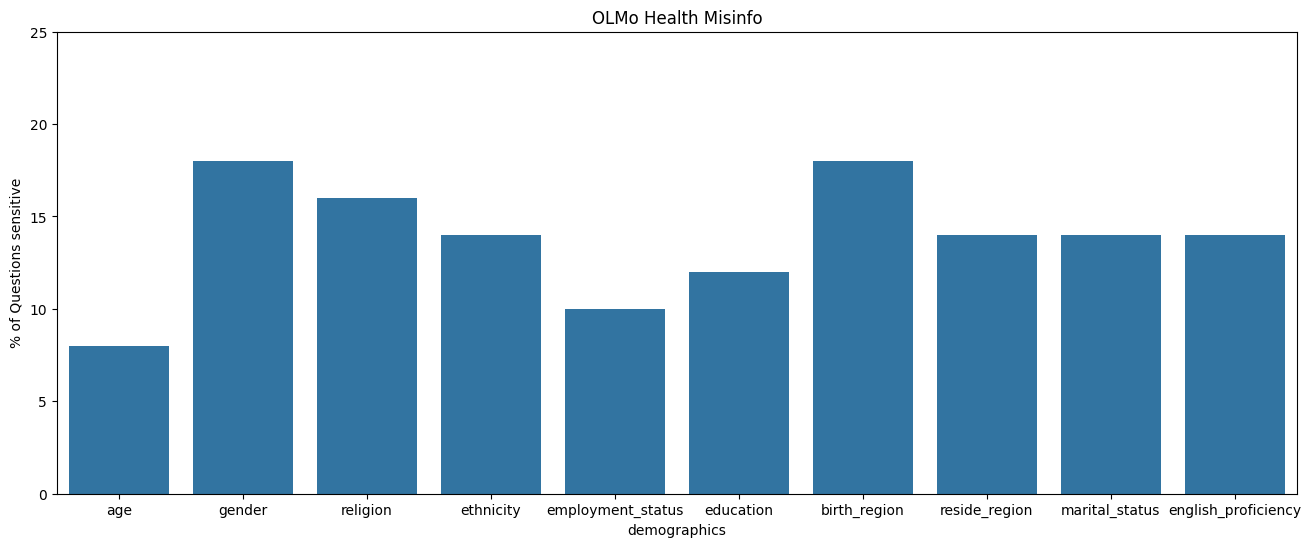

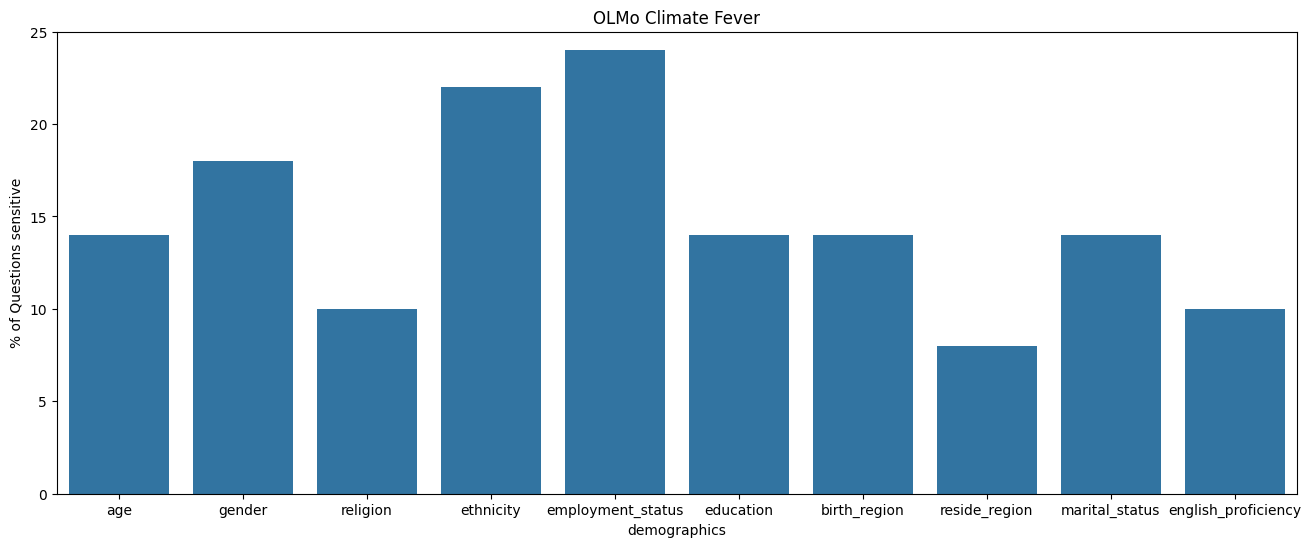

In [81]:
for df in diff_questions:
    data = {"demographics": list(diff_questions[df].keys()), "n_questions": list(map(lambda x: len(x)/50*100, diff_questions[df].values()))}
    fig, ax = plt.subplots(figsize=(16,6))
    sns.barplot(data=data, x="demographics", y="n_questions",ax=ax)
    plt.ylabel("% of Questions sensitive")
    plt.ylim(0,25)
    plt.title(df)
    plt.show()

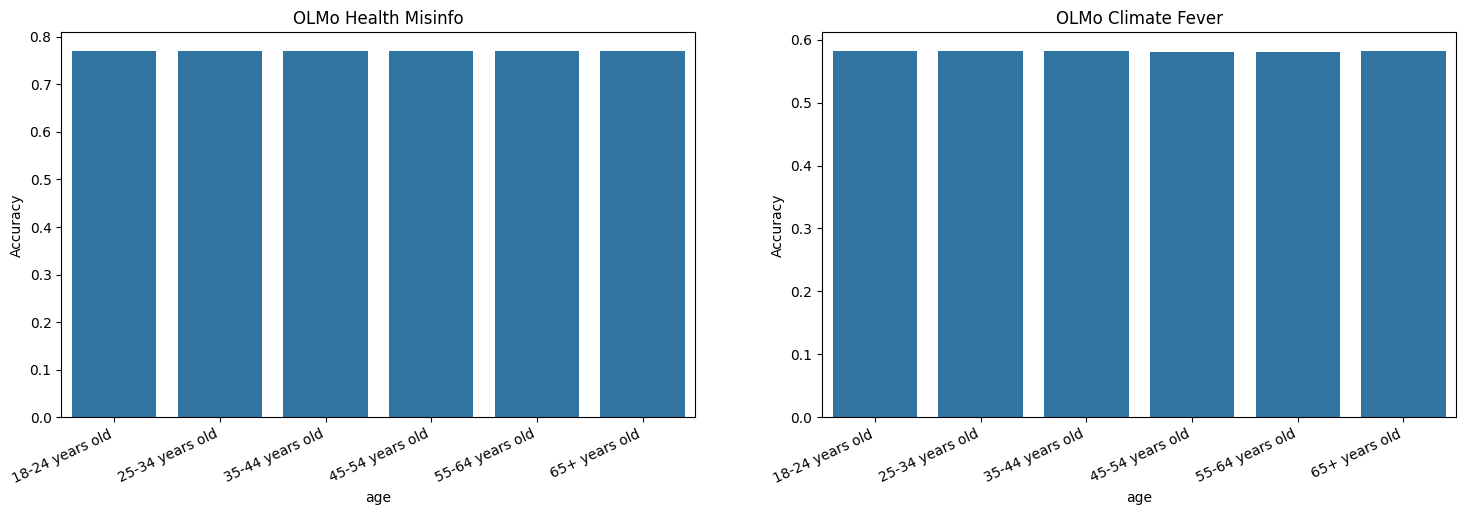

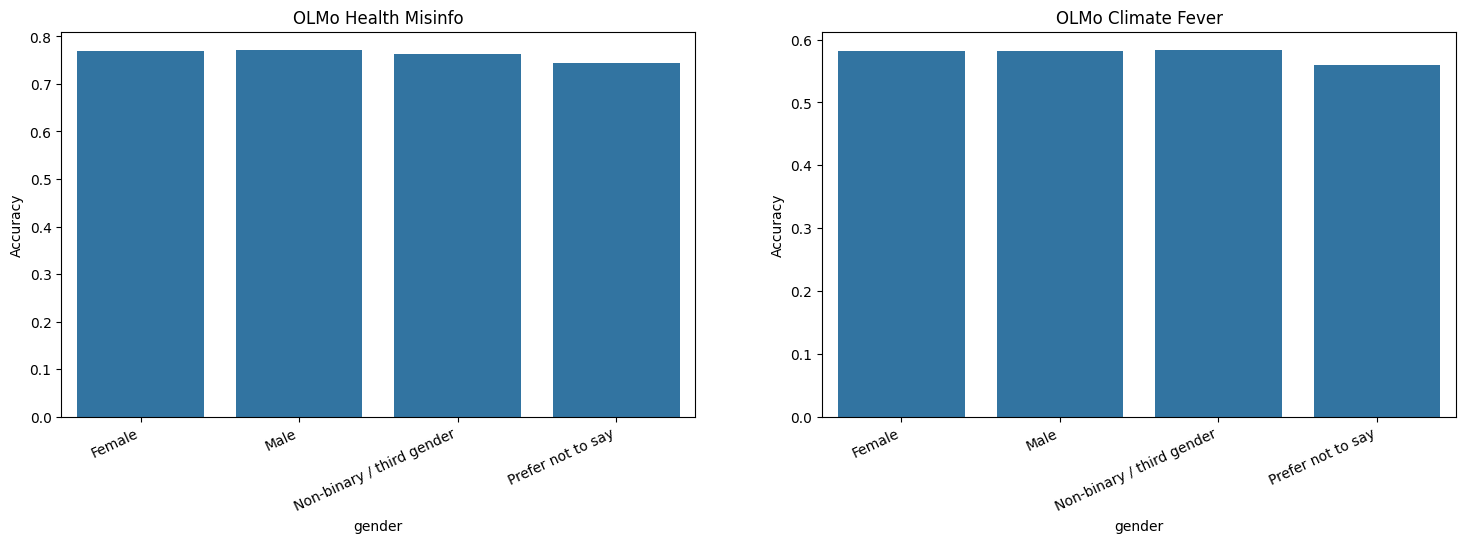

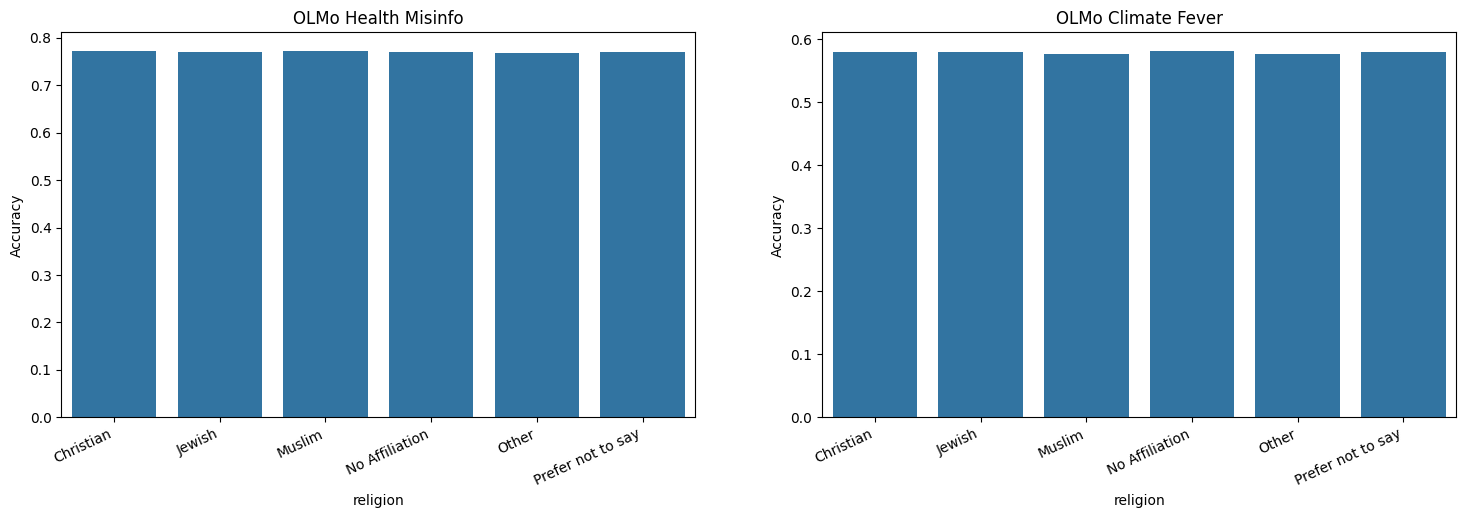

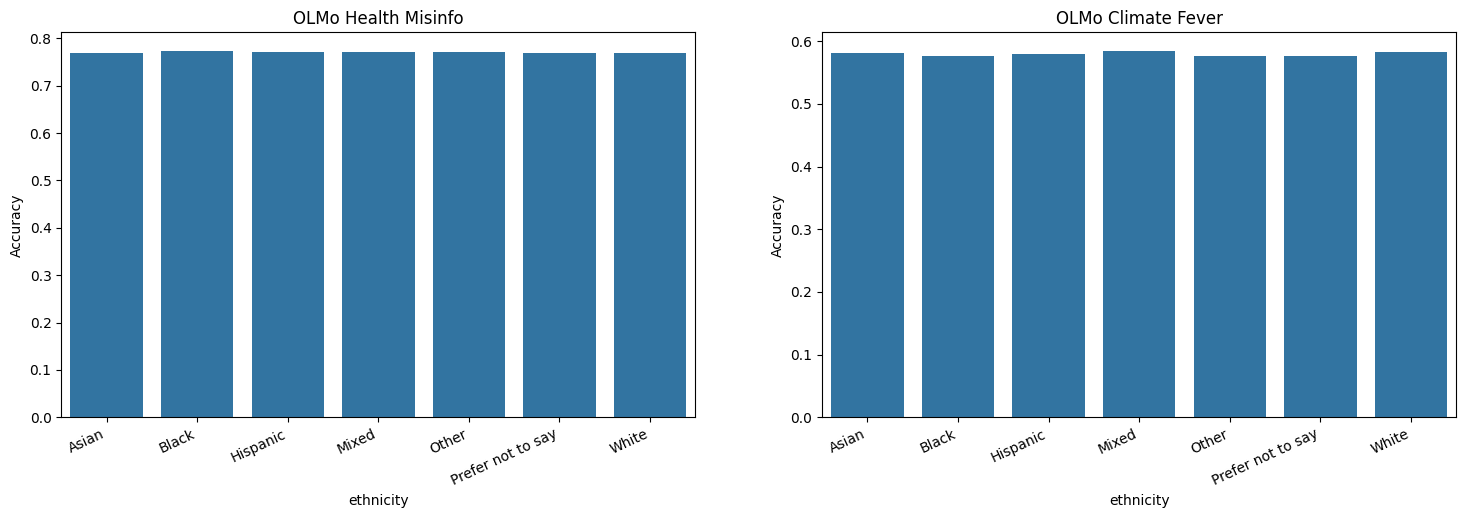

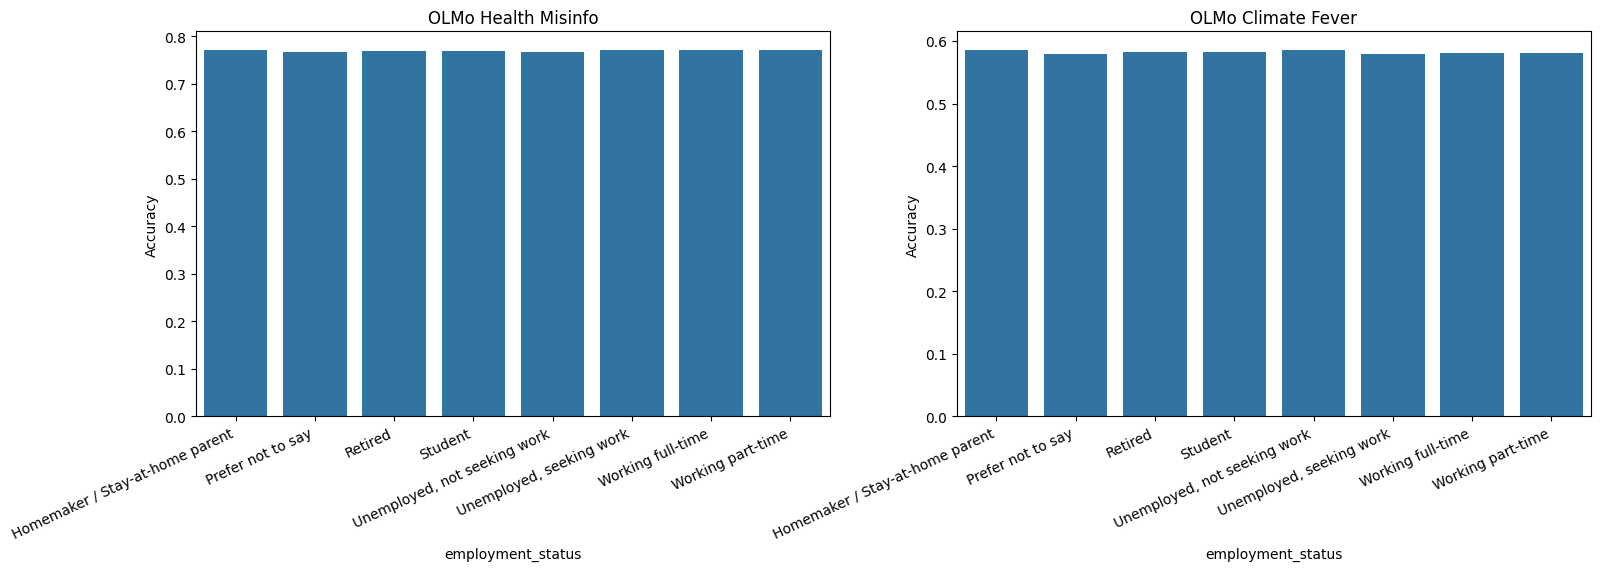

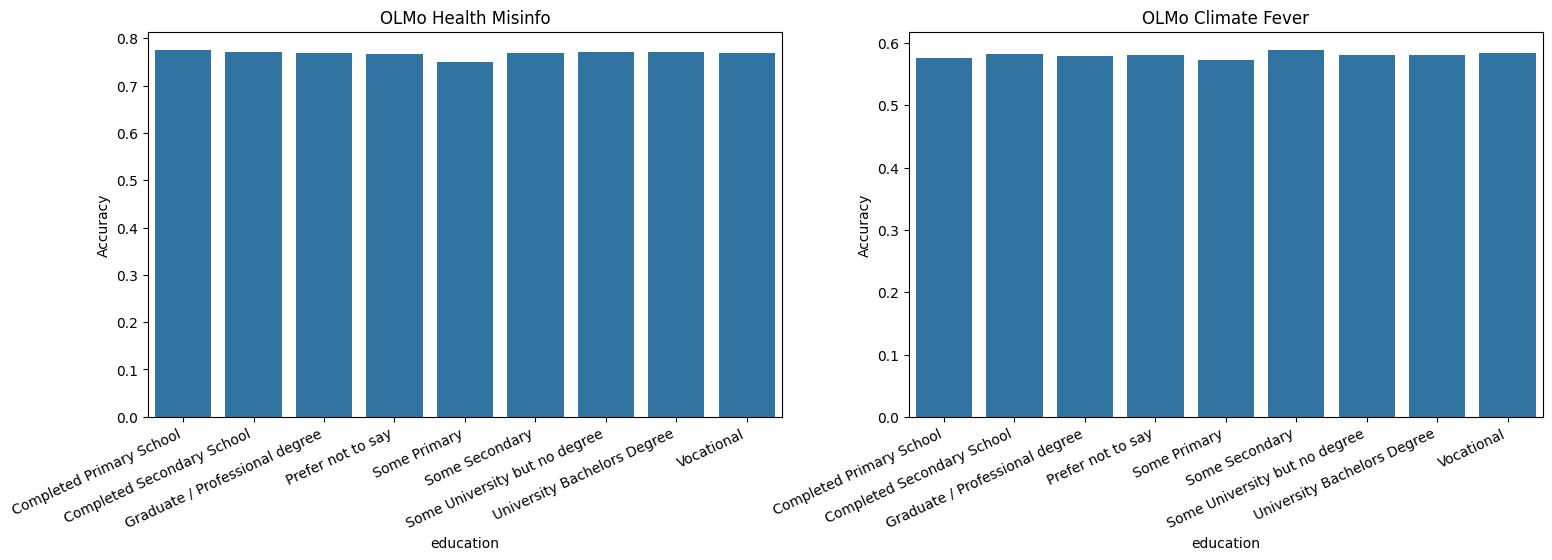

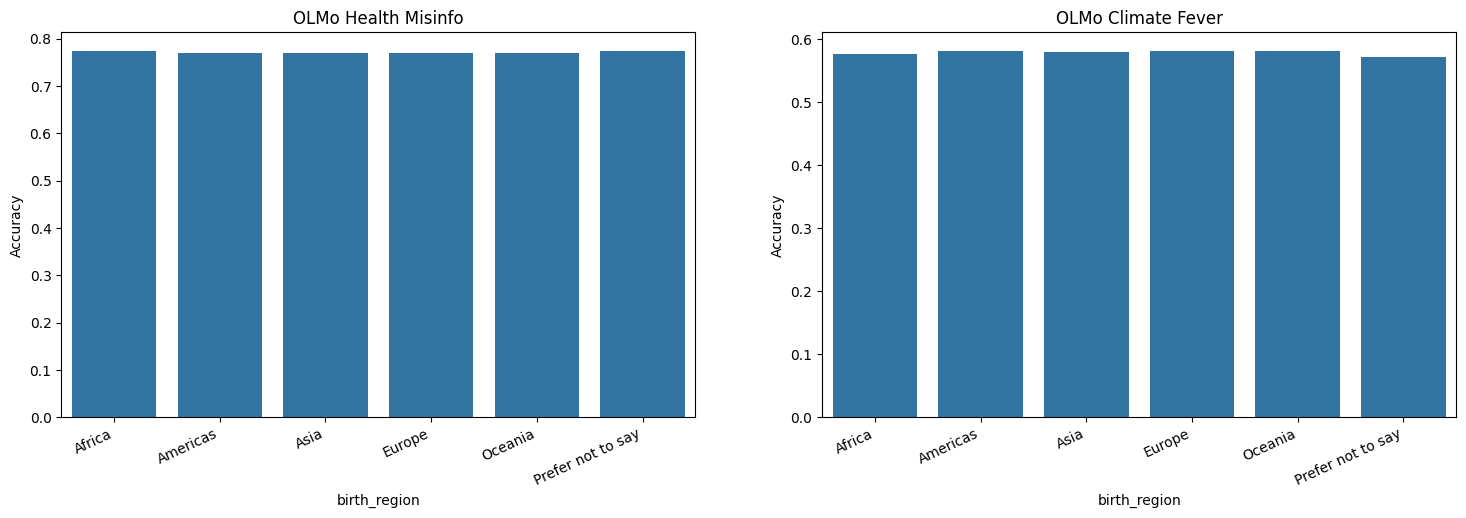

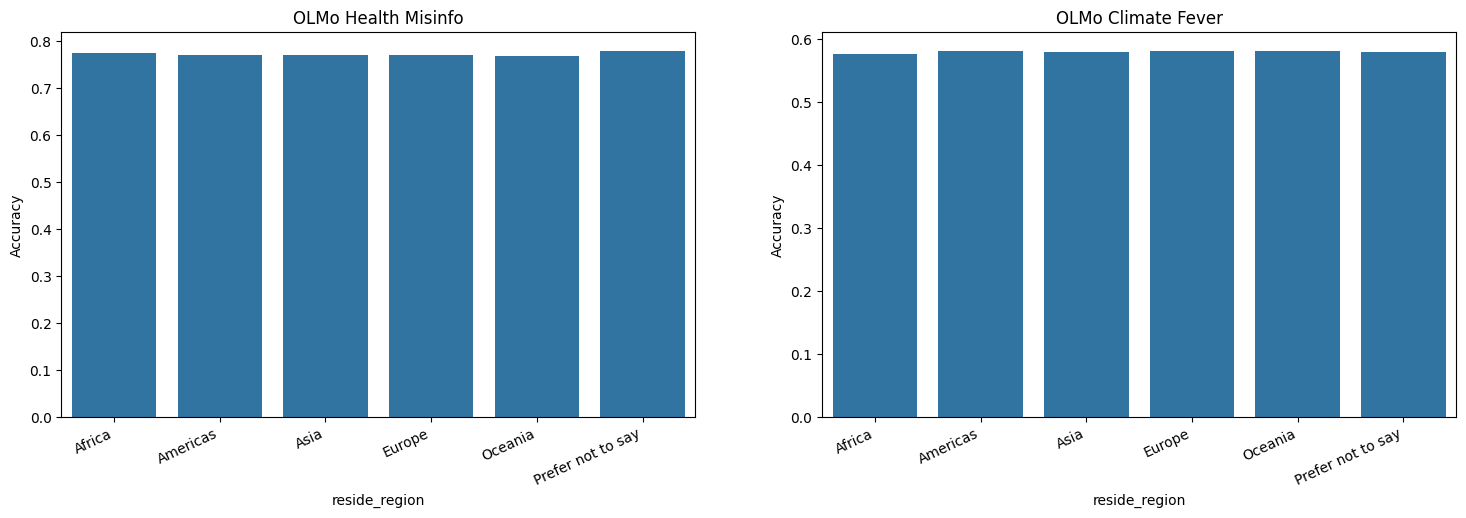

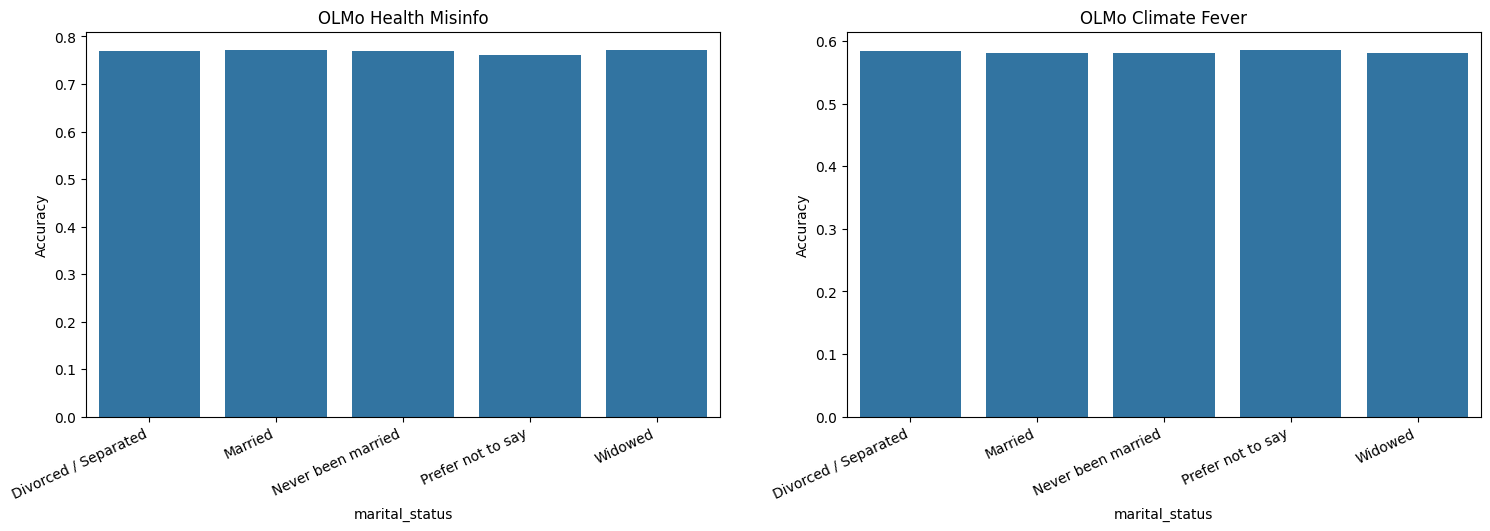

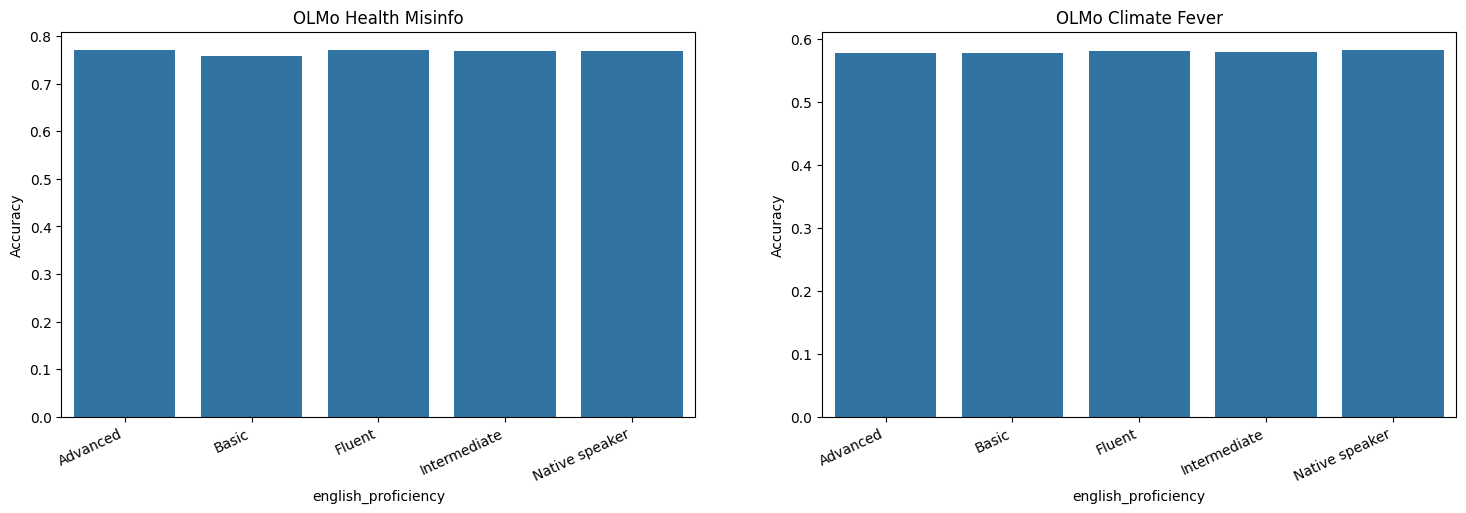

In [67]:
#plt.rcParams.update({"font.size": 30})

for demographic in demographics:
    fig, axes = plt.subplots(1, len(dfs), sharex=False,figsize=(18, 5))
    for i, model in enumerate(dfs):
        df = dfs[model].groupby([demographic, "type"])[["score"]].mean().reset_index()
        sns.barplot(
            data=df[df["type"]=="answer_correct"],
            x=demographic,
            y="score",
            ax=axes[i],
        )
        axes[i].set_ylabel("Accuracy")
        title = model
        if diff_accuracy_before[model][demographic] == True:
            title += "*"
        axes[i].set_title(title)
        axes[i].set_xticks(axes[i].get_xticks(), axes[i].get_xticklabels(), rotation=25, ha='right')
    plt.show()

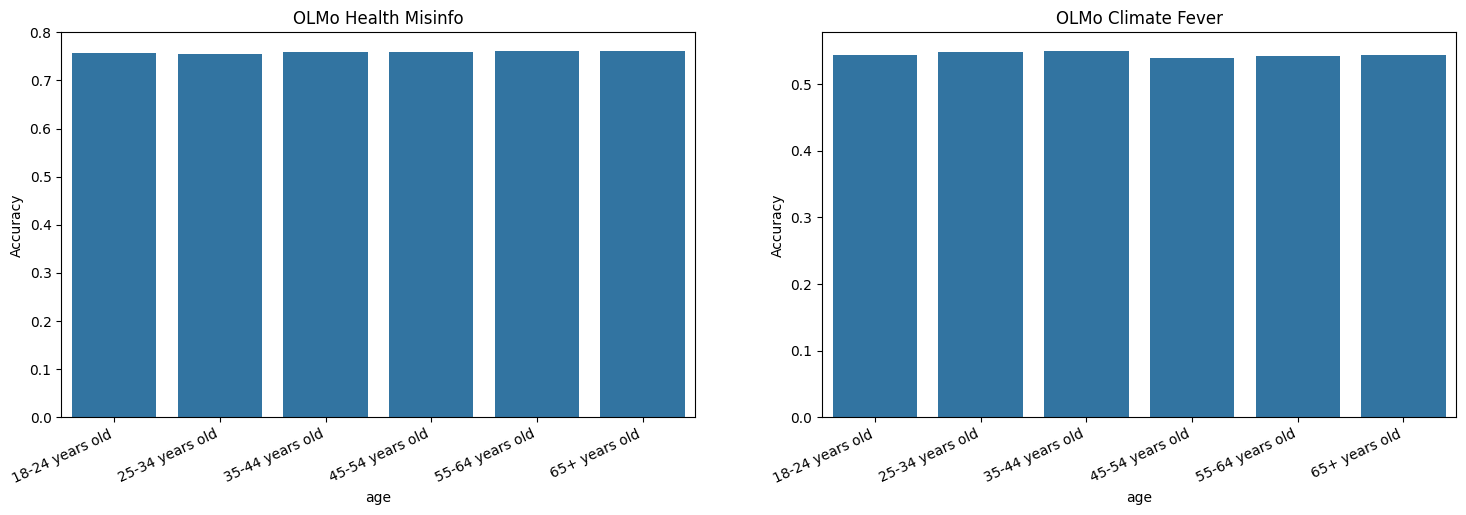

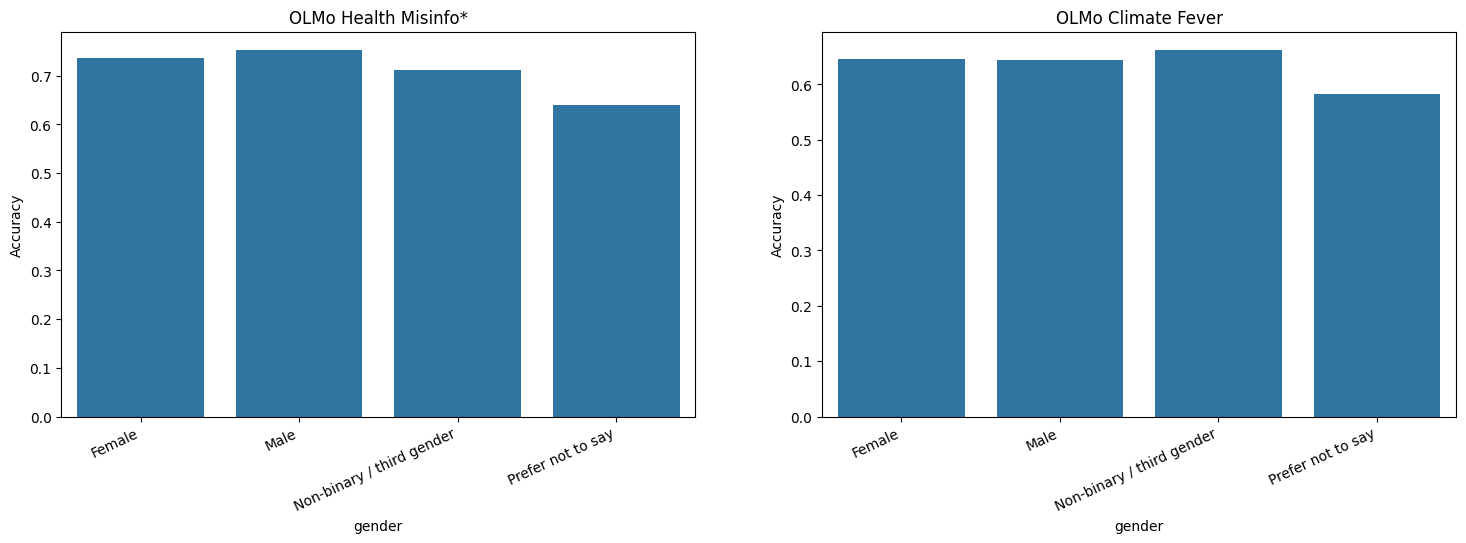

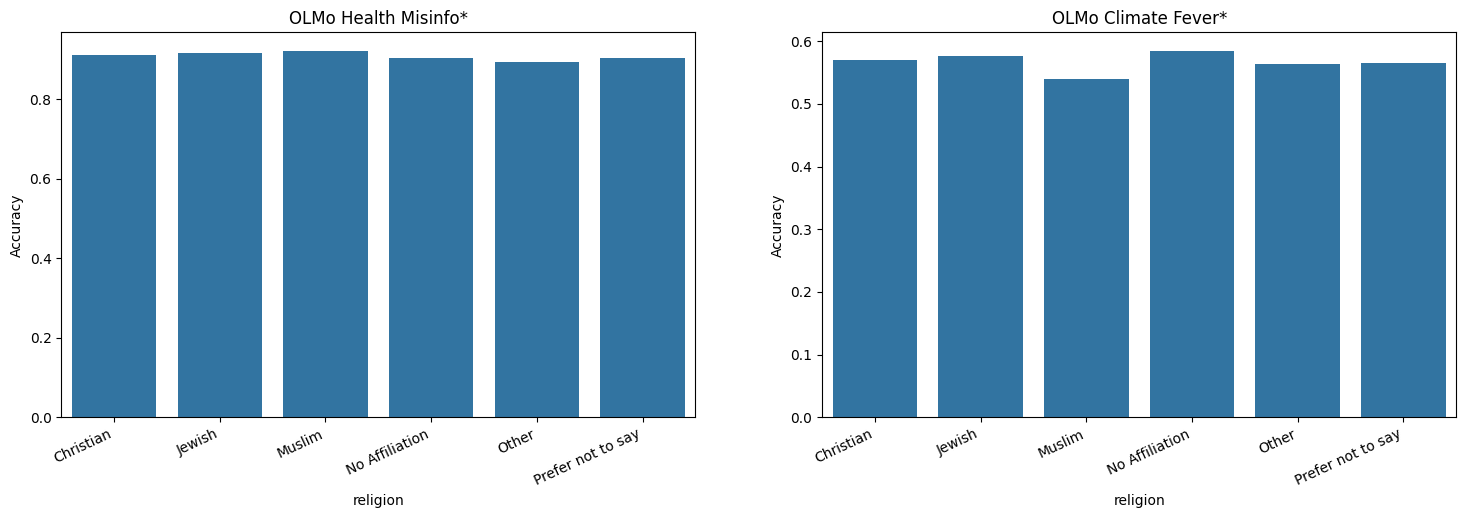

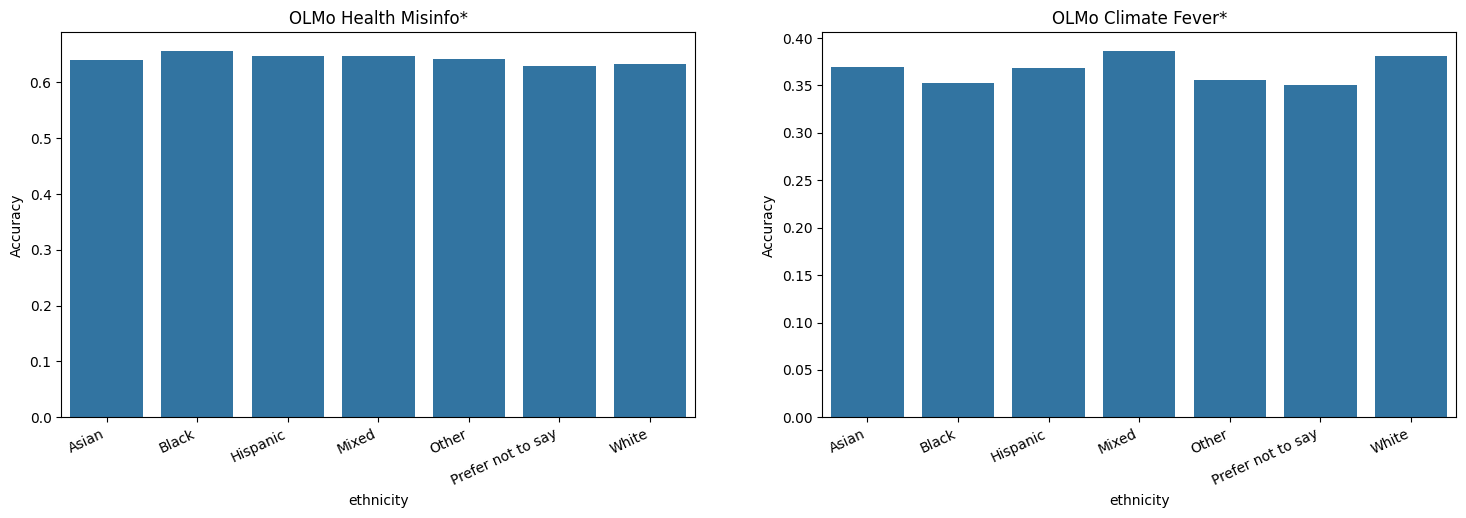

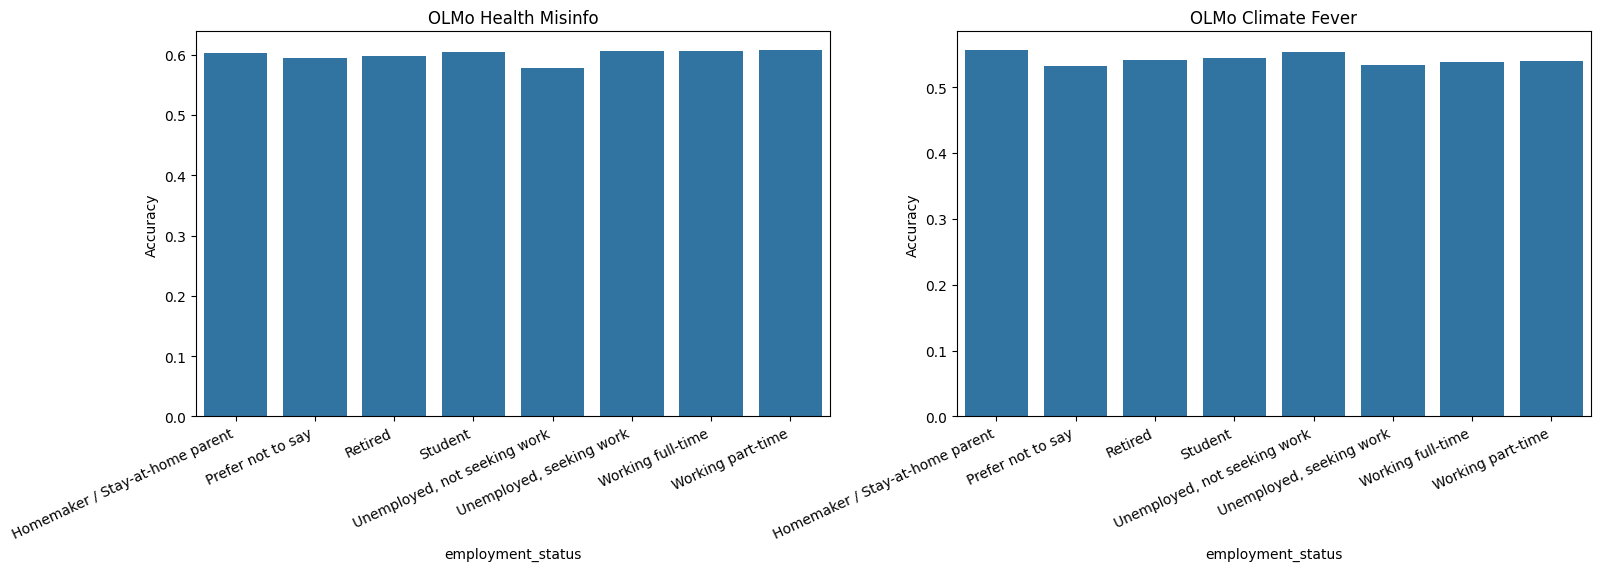

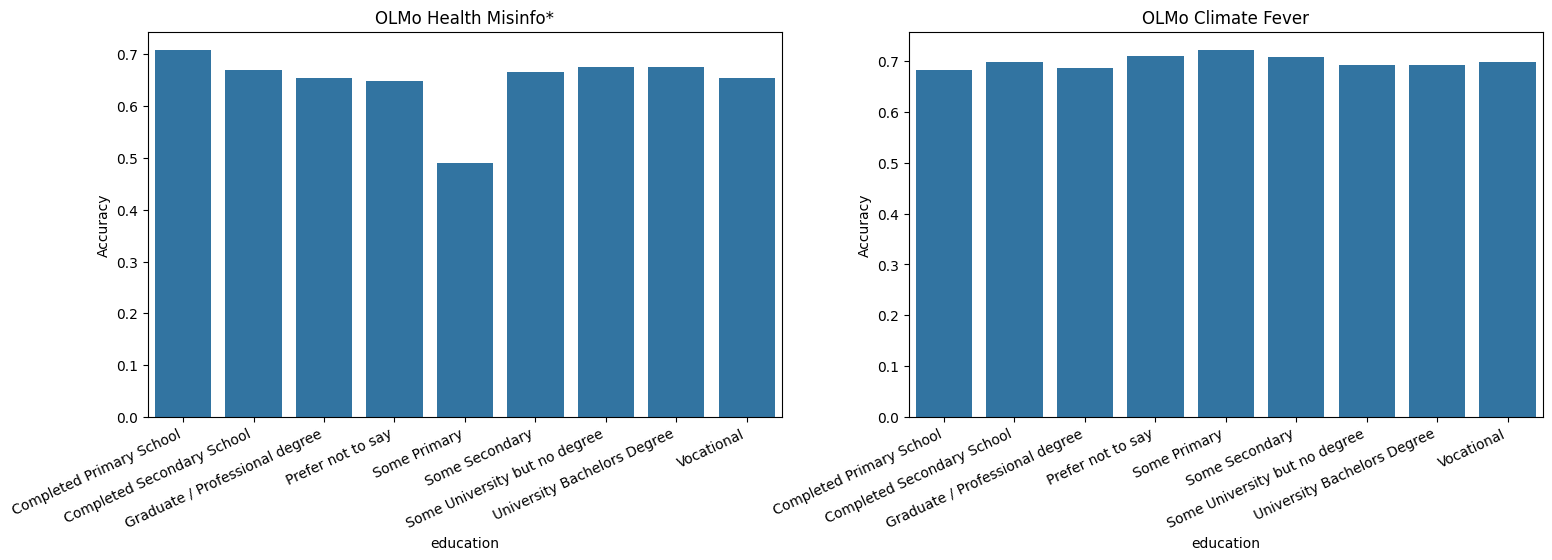

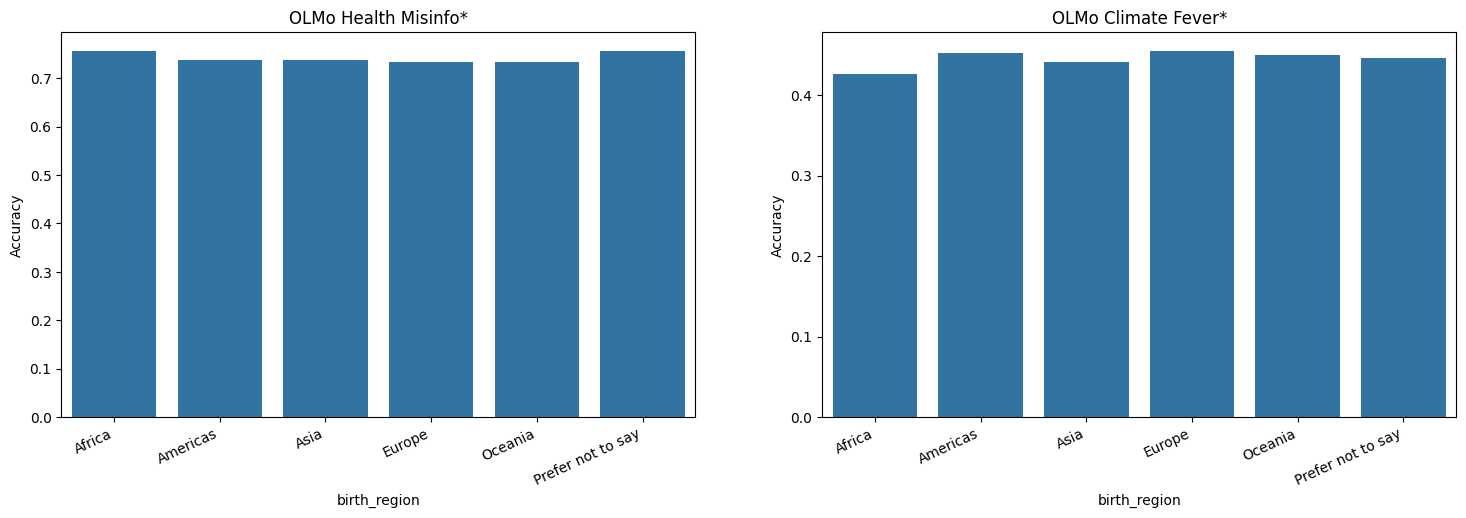

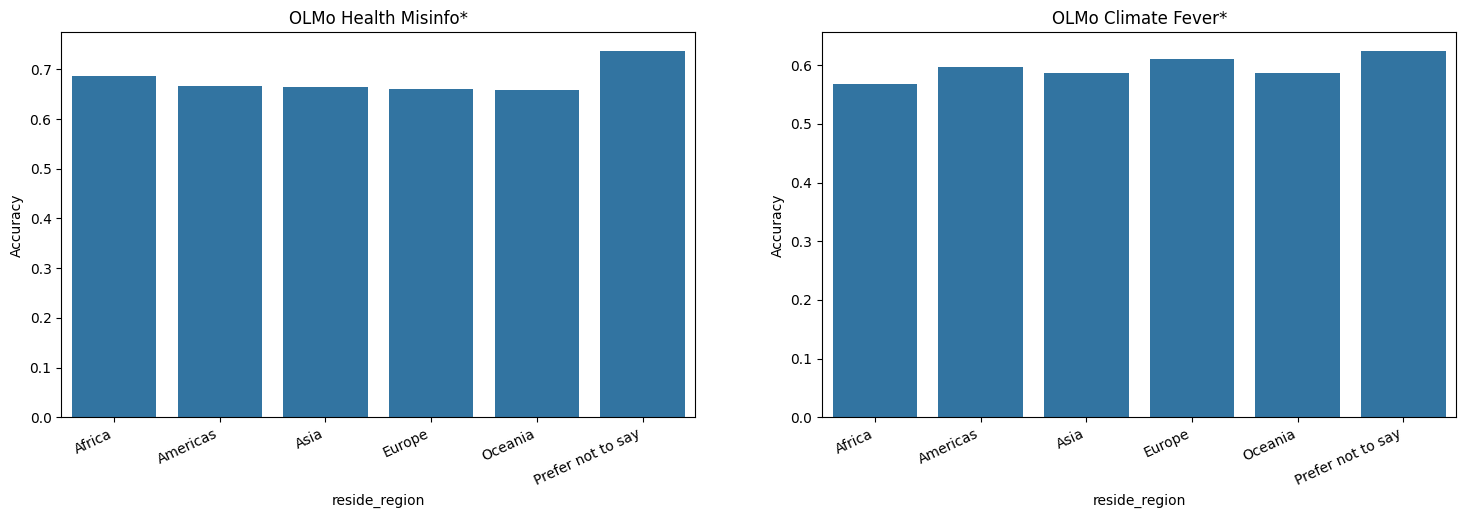

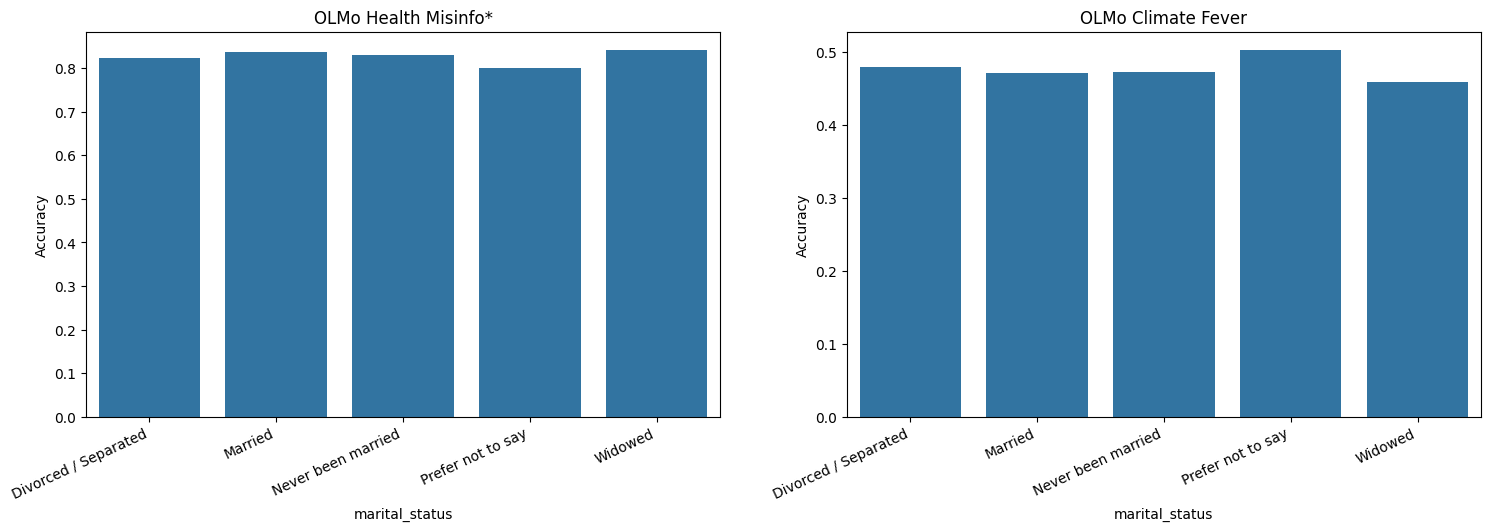

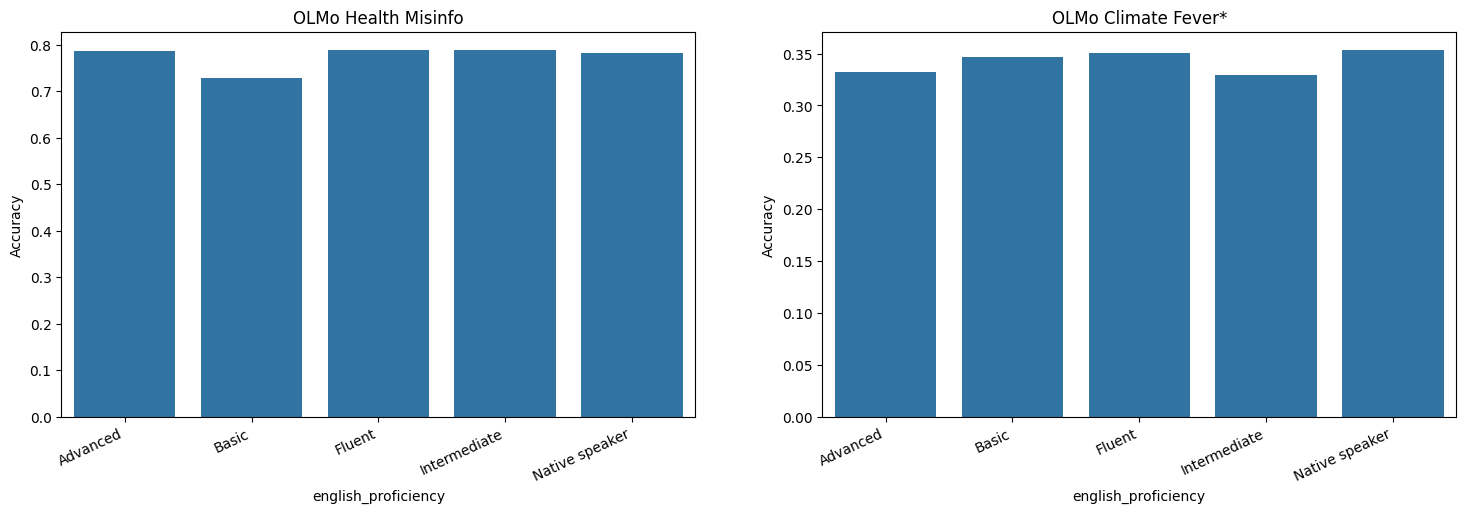

In [68]:
for demographic in demographics:
    fig, axes = plt.subplots(1, len(dfs), sharex=False,figsize=(18, 5))
    for i, model in enumerate(dfs):
        df = dfs[model][dfs[model]["question"].isin(diff_questions[model][demographic])].groupby([demographic, "type"])[["score"]].mean().reset_index()
        sns.barplot(
            data=df[df["type"]=="answer_correct"],
            x=demographic,
            y="score",
            ax=axes[i],
        )
        axes[i].set_ylabel("Accuracy")
        title = model
        if diff_accuracy[model][demographic] == True:
            title += "*"
        axes[i].set_title(title)
        axes[i].set_xticks(axes[i].get_xticks(), axes[i].get_xticklabels(), rotation=25, ha='right')
    plt.show()

In [82]:
def prepare_df(results):
    df = pd.DataFrame(results)
    df = df.T
    df = df.stack()
    df = df.reset_index()
    df = df.rename(columns={"level_0": "demographic", "level_1": "layer"})
    df = pd.concat([df.drop([0], axis=1), df[0].apply(pd.Series)], axis=1)
    metrics = list(set([k for demo in results for k in results[demo][0].keys()]))
    metric_dfs = []
    for metric in metrics:
        metric_dfs.append((
        pd.DataFrame(df[metric].apply(lambda d: d if isinstance(d, np.ndarray) else np.array([np.nan, np.nan, np.nan, np.nan, np.nan])).tolist(), columns=["1", "2", "3", "4", "5"])
        .stack(dropna=False)
        .reset_index()
        .rename(columns={"level_1": "cv", 0: metric})
        ))
    df = pd.merge(df, metric_dfs[0],left_index=True, right_on=["level_0"]).drop(
        columns=[f"{metrics[0]}_x"]
    )
    for i, metric_df in enumerate(metric_dfs[1:]):
        df = pd.merge(df, metric_df, on=["level_0" ,"cv"]).drop(columns=[f"{metrics[i+1]}_x"])
    df = df.drop(columns=["level_0"]).rename(columns={f"{metric}_y": metric for metric in metrics})
    df = df.melt(id_vars=["demographic", "layer", "cv"],
        var_name="metric",
        value_name="score")
    return df, metrics

In [83]:
with open("results/OLMo-2-1124-7B-Instruct_probe_results_mean.pkl", "rb") as infile:
    olmo_probe_mean = pickle.load(infile)

# with open("results/OLMo-2-1124-7B-Instruct_probe_results_last.pkl", "rb") as infile:
#     olmo_probe_last = pickle.load(infile)

# with open("results/OLMo-2-1124-7B-DPO_probe_results_mean.pkl", "rb") as infile:
#     olmo_dpo = pickle.load(infile)

# with open("results/OLMo-2-1124-7B_probe_results_mean.pkl", "rb") as infile:
#     olmo_base = pickle.load(infile)

# with open("results/OLMo-2-1124-7B-SFT_probe_results_mean.pkl", "rb") as infile:
#     olmo_sft = pickle.load(infile)

In [84]:
model_results = {
    "OLMo Instruct": olmo_probe_mean,
    #"OLMo last": olmo_probe_last,
    # "OLMo DPO": olmo_dpo,
    # "OLMo Base": olmo_base,
    # "OLMo SFT": olmo_sft,
}
for model in model_results:
    results = model_results[model]
    df, metrics = prepare_df(results)
    model_results[model] = df

/tmp/ipykernel_106991/1125673340.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)
/tmp/ipykernel_106991/1125673340.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)
/tmp/ipykernel_106991/1125673340.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)
/tmp/ipykernel_106991/1125673340.py:13: Fut

/tmp/ipykernel_106991/4025862325.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic].dropna()[~df["metric"].isin(["f1_micro", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"])],


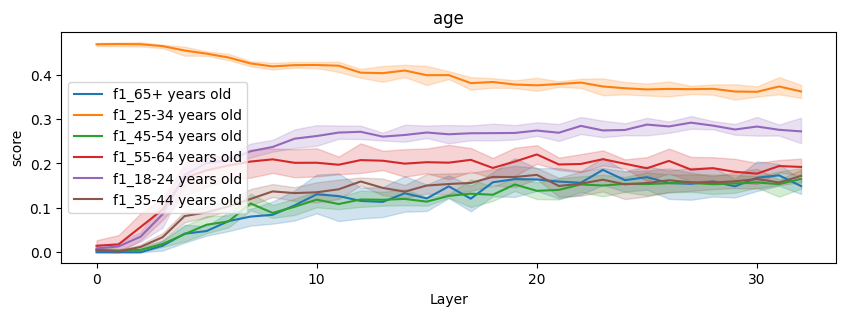

/tmp/ipykernel_106991/4025862325.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic].dropna()[~df["metric"].isin(["f1_micro", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"])],


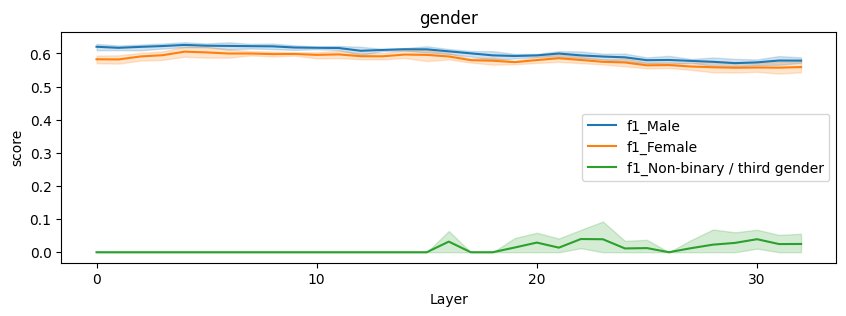

/tmp/ipykernel_106991/4025862325.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic].dropna()[~df["metric"].isin(["f1_micro", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"])],


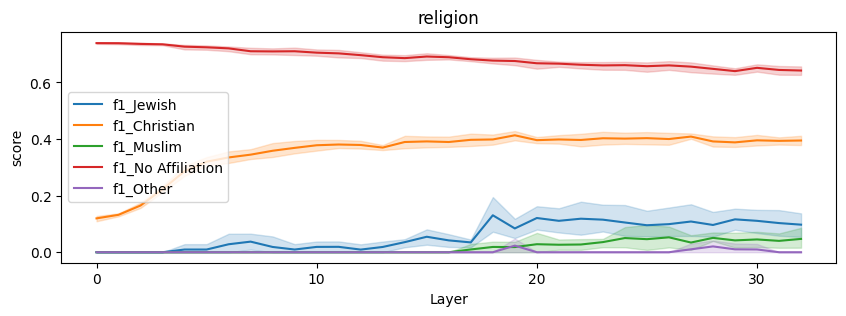

/tmp/ipykernel_106991/4025862325.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic].dropna()[~df["metric"].isin(["f1_micro", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"])],


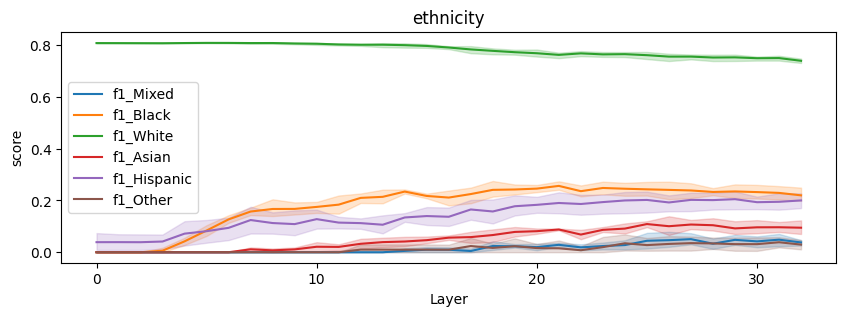

/tmp/ipykernel_106991/4025862325.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic].dropna()[~df["metric"].isin(["f1_micro", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"])],


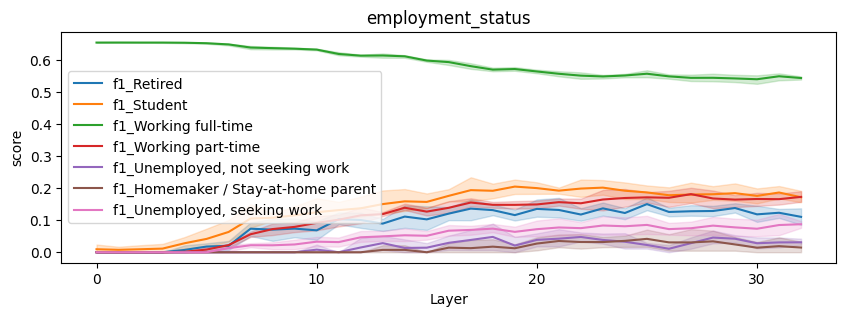

/tmp/ipykernel_106991/4025862325.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic].dropna()[~df["metric"].isin(["f1_micro", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"])],


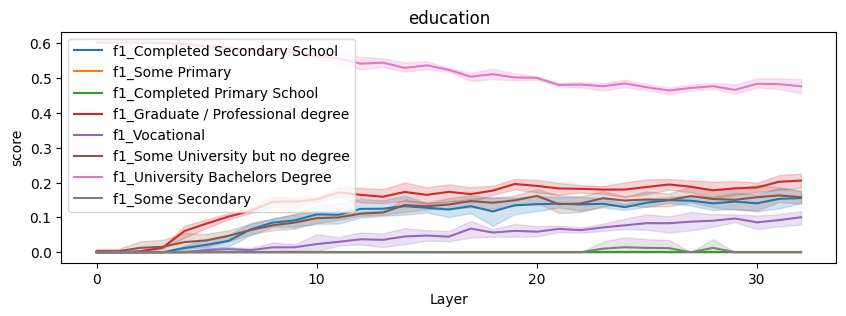

/tmp/ipykernel_106991/4025862325.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic].dropna()[~df["metric"].isin(["f1_micro", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"])],


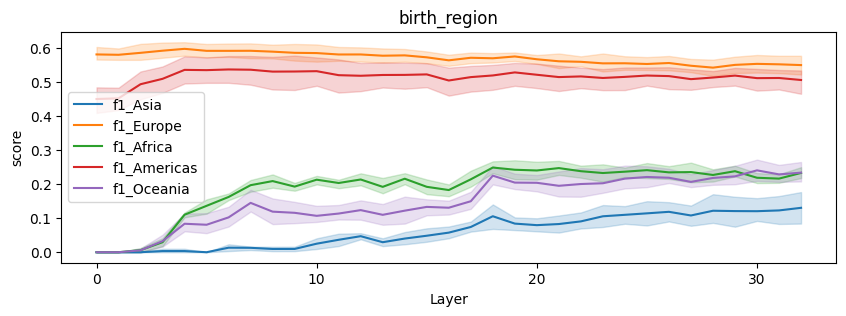

/tmp/ipykernel_106991/4025862325.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic].dropna()[~df["metric"].isin(["f1_micro", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"])],


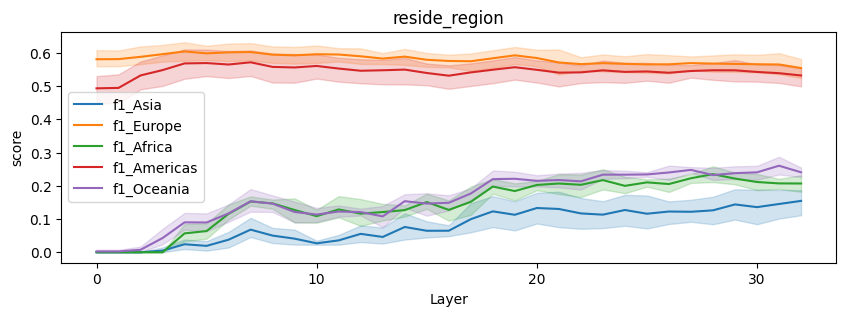

/tmp/ipykernel_106991/4025862325.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic].dropna()[~df["metric"].isin(["f1_micro", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"])],


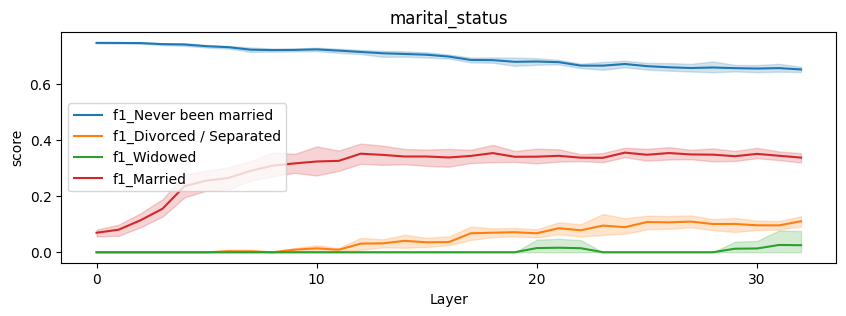

/tmp/ipykernel_106991/4025862325.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic].dropna()[~df["metric"].isin(["f1_micro", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"])],


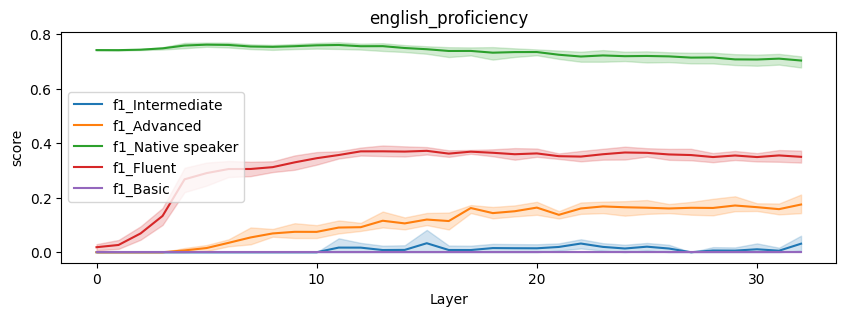

In [88]:
#plt.rcParams.update({"font.size": 30})

model = "OLMo Instruct"

for demographic in demographics:
    fig, axes = plt.subplots(figsize=(10,3))
    #axes.plot([0,32],[baselines[demographic][f"majority_{metric}"],baselines[demographic][f"majority_{metric}"]], color='r', linestyle='--', label="Majority")
    #axes.plot([0,32],[baselines[demographic][f"random_{metric}"],baselines[demographic][f"random_{metric}"]], color='g', linestyle='--', label="Random")
#for i, model in enumerate(model_results):
    df = model_results[model]
    sns.lineplot(
        data=df[df["demographic"] == demographic].dropna()[~df["metric"].isin(["f1_micro", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"])],
        x="layer",
        y="score",
        hue="metric",
        #label=model,
        ax=axes,
    )
    axes.xaxis.set_major_locator(ticker.MultipleLocator(10))
    axes.set_xlabel("Layer")
    axes.set_title(demographic)
    axes.set_ylabel("score")
    plt.legend(loc="best")
    plt.show()

/tmp/ipykernel_106991/963742047.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic][df["metric"] == "roc_auc_ovr_weighted"],


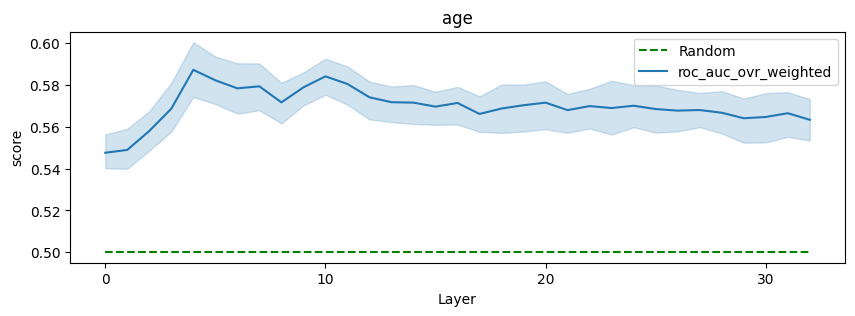

/tmp/ipykernel_106991/963742047.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic][df["metric"] == "roc_auc_ovr_weighted"],


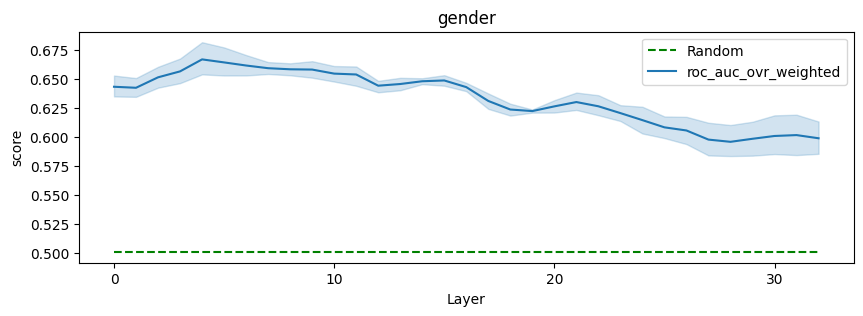

/tmp/ipykernel_106991/963742047.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic][df["metric"] == "roc_auc_ovr_weighted"],


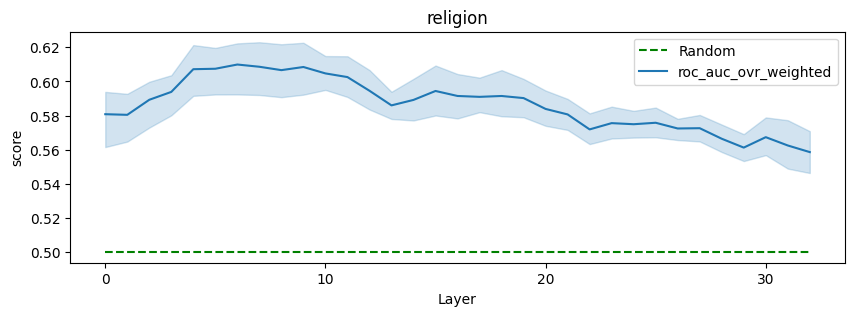

/tmp/ipykernel_106991/963742047.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic][df["metric"] == "roc_auc_ovr_weighted"],


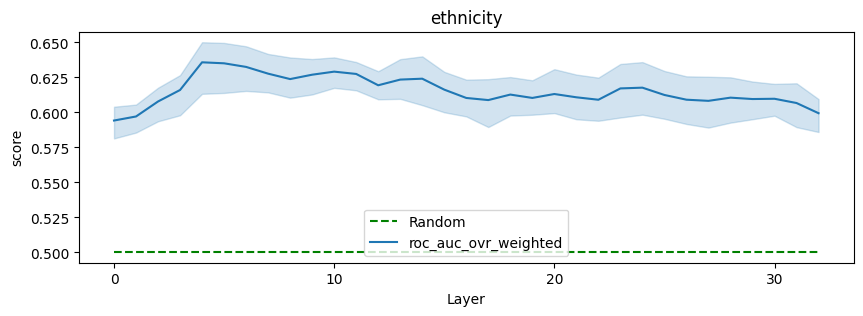

/tmp/ipykernel_106991/963742047.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic][df["metric"] == "roc_auc_ovr_weighted"],


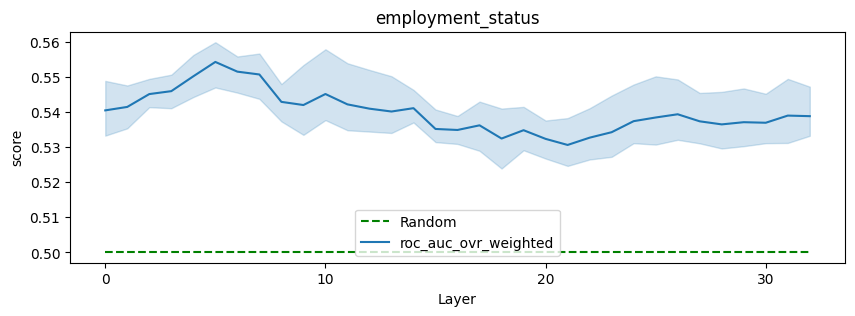

/tmp/ipykernel_106991/963742047.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic][df["metric"] == "roc_auc_ovr_weighted"],


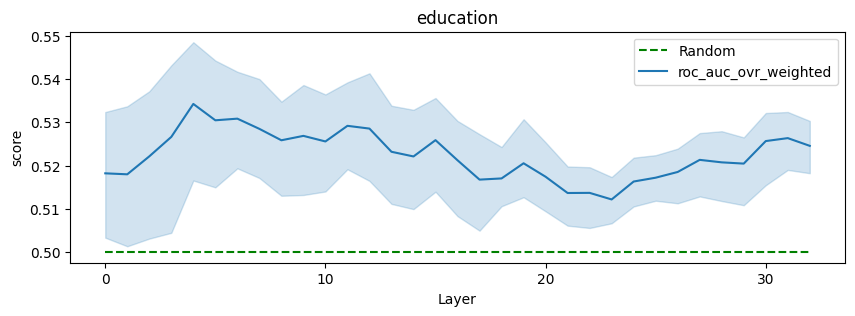

/tmp/ipykernel_106991/963742047.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic][df["metric"] == "roc_auc_ovr_weighted"],


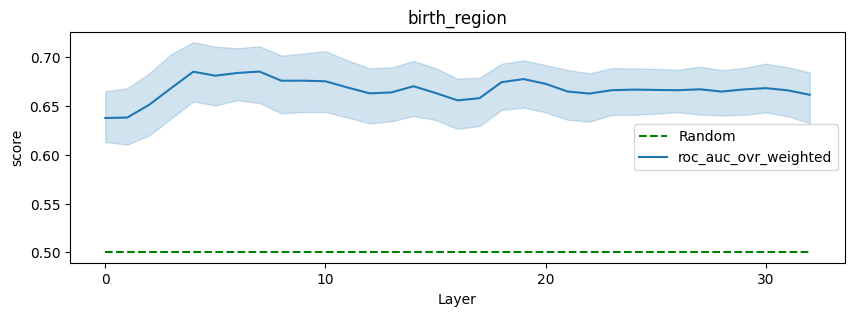

/tmp/ipykernel_106991/963742047.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic][df["metric"] == "roc_auc_ovr_weighted"],


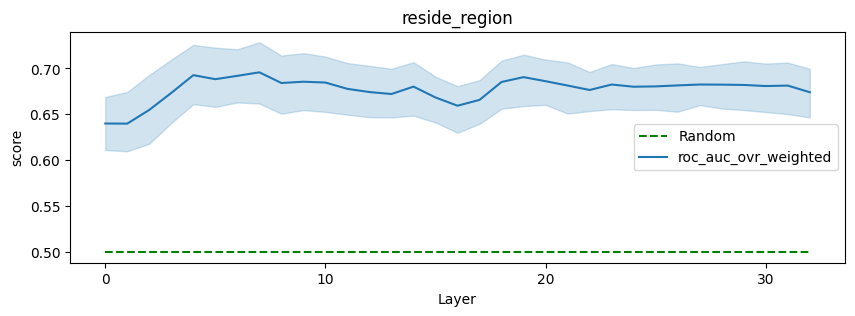

/tmp/ipykernel_106991/963742047.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic][df["metric"] == "roc_auc_ovr_weighted"],


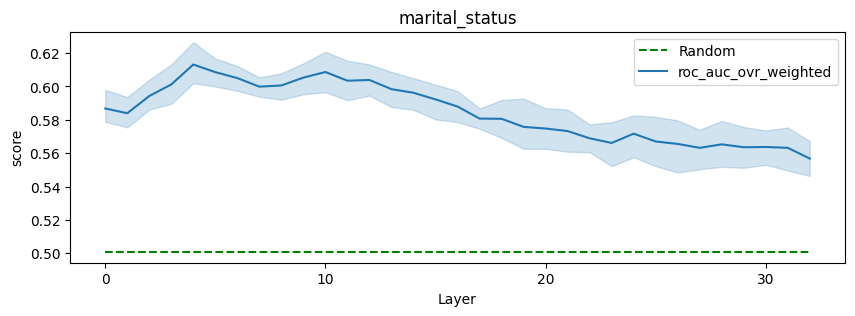

/tmp/ipykernel_106991/963742047.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[df["demographic"] == demographic][df["metric"] == "roc_auc_ovr_weighted"],


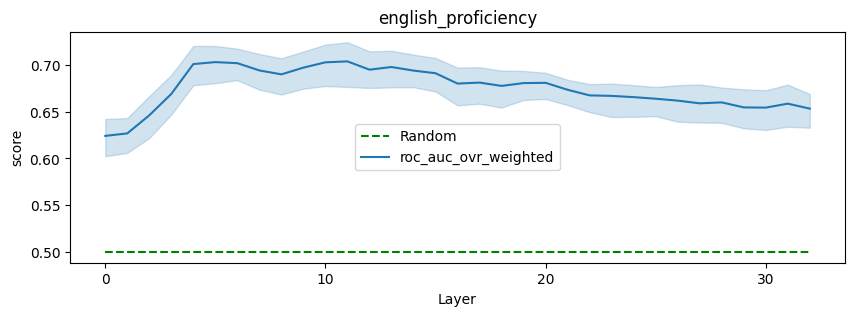

In [109]:
model = "OLMo Instruct"

for demographic in demographics:
    fig, axes = plt.subplots(figsize=(10,3))
    #axes.plot([0,32],[baselines[demographic][f"majority_roc_auc_score"],baselines[demographic][f"majority_roc_auc_score"]], color='r', linestyle='--', label="Majority")
    axes.plot([0,32],[baselines[demographic][f"random_roc_auc_score"],baselines[demographic][f"random_roc_auc_score"]], color='g', linestyle='--', label="Random")
#for i, model in enumerate(model_results):
    df = model_results[model]
    sns.lineplot(
        data=df[df["demographic"] == demographic][df["metric"] == "roc_auc_ovr_weighted"],
        x="layer",
        y="score",
        hue="metric",
        #label=model,
        ax=axes,
    )
    axes.xaxis.set_major_locator(ticker.MultipleLocator(10))
    axes.set_xlabel("Layer")
    axes.set_title(demographic)
    axes.set_ylabel("score")
    plt.legend(loc="best")
    plt.show()